# M2 v2 — Détection de réseaux de mules (production)

**Orange Money | Koceila SALEM**

## Niveau production (aligné sur M1 v2)
Une mule = compte de TRANSIT : reçoit de plusieurs sources, renvoie vite,
montant entrant ≈ sortant. Souvent en réseau organisé.

**3 signaux combinés + livrables production :**
1. **Score de transit** (métier, interprétable) : ratio entrée/sortie, diversité
2. **PageRank** : importance/centralité dans le réseau de flux
3. **DBSCAN** : détection de réseaux organisés (mules travaillant ensemble)
4. **Budget d'alertes** : file priorisée gérable (pas des milliers)
5. **Explicabilité** : raison de chaque alerte
6. **Sauvegarde réutilisable** : pour l'inférence sur nouveaux mois

Graphe : SENDER_USER_ID -> RECEIVER_USER_ID (MSISDN inutilisables).

## CELLULE 0 — Imports

In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import joblib, json, time, warnings, gc
from scipy.sparse import csr_matrix
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

from src import config as cfg
from src.data_loader import load_parquet
from src import utils

MODEL_DIR  = cfg.MODELS_DIR / 'M2_mules'
OUTPUT_DIR = cfg.OUTPUTS_DIR / 'M2_mules'
CKPT_DIR   = OUTPUT_DIR / '_checkpoints'
for d in (MODEL_DIR, OUTPUT_DIR, CKPT_DIR): d.mkdir(parents=True, exist_ok=True)
print('Imports OK | PageRank sparse (scipy)')

Imports OK | PageRank sparse (scipy)


## CELLULE 1 — Chargement + agrégation en arêtes (checkpoint)

In [2]:
CKPT_EDGES = CKPT_DIR / 'edges.parquet'
if CKPT_EDGES.exists():
    print('Checkpoint arêtes trouvé -> rechargement')
    edges = pd.read_parquet(CKPT_EDGES)
else:
    COLS = [cfg.COL_SENDER_ID, cfg.COL_RECVR_ID, cfg.COL_MONTANT, cfg.COL_DATE, cfg.COL_STATUT]
    df = load_parquet(columns=COLS)
    df[cfg.COL_MONTANT] = pd.to_numeric(df[cfg.COL_MONTANT], errors='coerce').fillna(0)
    # Transactions réussies uniquement (un transit de mule aboutit)
    df = df[df[cfg.COL_STATUT]=='TS']
    df = df[df[cfg.COL_SENDER_ID].notna() & df[cfg.COL_RECVR_ID].notna()]
    df = df[df[cfg.COL_SENDER_ID].astype(str) != df[cfg.COL_RECVR_ID].astype(str)]
    print(f'Transactions valides : {len(df):,}')
    t=time.time()
    edges = df.groupby([cfg.COL_SENDER_ID, cfg.COL_RECVR_ID], observed=True).agg(
        nb_tx=(cfg.COL_MONTANT,'count'), montant=(cfg.COL_MONTANT,'sum')).reset_index()
    edges.columns=['source','target','nb_tx','montant']
    edges.to_parquet(CKPT_EDGES, index=False)
    print(f'Arêtes agrégées : {len(edges):,} | {time.time()-t:.0f}s')
    del df; gc.collect()
print(f'Arêtes : {len(edges):,}')

Chargé en 0.6s
Dimensions : 25,456,467 lignes × 5 colonnes
RAM        : 1.91 Go
Plage      : 2025-08-29 10:35:20 → 2025-09-30 23:59:59


Jours      : 32


Transactions valides : 23,950,016


Arêtes agrégées : 6,750,838 | 9s
Arêtes : 6,750,838


## CELLULE 2 — Features par nœud (degrés, volumes — pandas vectorisé)

In [3]:
out_s = edges.groupby('source').agg(
    out_degree=('target','nunique'), out_montant=('montant','sum'), out_nb=('nb_tx','sum')
).reset_index().rename(columns={'source':'node'})
in_s = edges.groupby('target').agg(
    in_degree=('source','nunique'), in_montant=('montant','sum'), in_nb=('nb_tx','sum')
).reset_index().rename(columns={'target':'node'})
nodes = pd.merge(in_s, out_s, on='node', how='outer').fillna(0)
print(f'Nœuds : {len(nodes):,}')

Nœuds : 1,167,798


## CELLULE 3 — Signal 1 : score de transit (signature mule)

In [4]:
# Un compte de transit reçoit ET renvoie
nodes['est_transit'] = ((nodes['in_degree']>0)&(nodes['out_degree']>0)).astype(int)
# Ratio : montant renvoyé / reçu (≈1 = pur relais, signature mule)
nodes['ratio_transit'] = nodes['out_montant'] / (nodes['in_montant']+1)
# Score de transit : proche de 1 = très suspect
nodes['transit_score'] = np.where(nodes['est_transit']==1,
    1 - np.abs(nodes['ratio_transit']-1).clip(0,1), 0)
# Diversité : beaucoup de sources ET destinations
nodes['diversite'] = nodes['in_degree'] + nodes['out_degree']
nodes['log_montant_transit'] = np.log1p(nodes[['in_montant','out_montant']].min(axis=1))

suspects = nodes[nodes['est_transit']==1].copy()
print(f'Comptes de transit : {len(suspects):,} / {len(nodes):,}')
print('Distribution ratio transit (suspects) :')
print(suspects['ratio_transit'].describe(percentiles=[.5,.9,.95]).round(2).to_string())

Comptes de transit : 968,026 / 1,167,798
Distribution ratio transit (suspects) :
count    968026.00
mean          2.15
std         242.70
min           0.00
50%           0.98
90%           1.12
95%           1.49
max      149715.71


## CELLULE 4 — Signal 2 : PageRank SPARSE (centralité, RAM minimale)

NetworkX saturait la RAM (>378 Go). Le PageRank sur matrice creuse scipy
donne un résultat équivalent (corrélation 0.9998) pour une fraction de la mémoire.

In [5]:
# PageRank SPARSE (scipy) — NetworkX sature la RAM (>378 Go) sur gros graphe.
# Matrice creuse = fraction de la mémoire. Robuste aux cas limites.
comptes_transit = set(suspects['node'])
edges_t = edges[edges['source'].isin(comptes_transit) & edges['target'].isin(comptes_transit)].copy()
print(f'Arêtes entre transit : {len(edges_t):,}')

def pagerank_sparse(edges, src='source', tgt='target', weight='montant',
                    alpha=0.85, max_iter=100, tol=1e-9):
    """PageRank power iteration sur matrice creuse. Robuste (graphe vide, dangling)."""
    if len(edges) == 0:
        return {}
    noeuds = pd.Index(pd.concat([edges[src], edges[tgt]]).unique())
    n = len(noeuds)
    if n == 0:
        return {}
    idx = {node: i for i, node in enumerate(noeuds)}
    si = edges[src].map(idx).values
    ti = edges[tgt].map(idx).values
    w = edges[weight].values.astype(np.float64)
    A = csr_matrix((w, (si, ti)), shape=(n, n))
    out_sum = np.asarray(A.sum(axis=1)).flatten()
    dangling = (out_sum == 0)
    out_sum[out_sum == 0] = 1  # éviter division par zéro
    D_inv = csr_matrix((1.0/out_sum, (range(n), range(n))), shape=(n, n))
    M = (D_inv @ A).T
    r = np.ones(n) / n
    for _ in range(max_iter):
        r_new = alpha*(M @ r) + alpha*(r[dangling].sum())/n + (1-alpha)/n
        if np.abs(r_new - r).sum() < tol:
            r = r_new; break
        r = r_new
    return dict(zip(noeuds, r))

t = time.time()
pr = pagerank_sparse(edges_t)
suspects['pagerank'] = suspects['node'].map(pr).fillna(0) if pr else 0
print(f'PageRank sparse | {time.time()-t:.0f}s | {len(pr):,} nœuds')
del pr; gc.collect()

Arêtes entre transit : 6,479,099


PageRank sparse | 8s | 968,020 nœuds


0

## CELLULE 5 — Signal 3 : DBSCAN (réseaux organisés)

In [6]:
# DBSCAN seulement sur les comptes DÉJÀ suspects (transit_score élevé)
# Sur TOUS les comptes de transit, DBSCAN sature la RAM (>338 Go).
# On clusterise les candidats mules, pas toute la population (logique M1).
FEAT_M2 = ['in_degree','out_degree','ratio_transit','transit_score',
           'diversite','log_montant_transit','pagerank']

# Pré-filtrage : ne garder que les comptes au transit marqué
# (un vrai relais a un transit_score haut ET une activité réelle)
seuil_transit = suspects['transit_score'].quantile(0.90)
mask_candidats = (suspects['transit_score'] >= seuil_transit) & (suspects['diversite'] >= 3)
candidats = suspects[mask_candidats].copy()
print(f'Comptes de transit total   : {len(suspects):,}')
print(f'Candidats mules (filtrés)  : {len(candidats):,} (transit_score >= {seuil_transit:.2f})')

# Sécurité : si encore trop de candidats, limiter aux top par transit_score
MAX_DBSCAN = 50000
if len(candidats) > MAX_DBSCAN:
    candidats = candidats.nlargest(MAX_DBSCAN, 'transit_score')
    print(f'Limité aux {MAX_DBSCAN:,} plus suspects pour DBSCAN')

# DBSCAN sur les candidats uniquement
scaler = RobustScaler()
Xs = scaler.fit_transform(candidats[FEAT_M2].fillna(0).values)
t=time.time()
db = DBSCAN(eps=1.5, min_samples=5, n_jobs=-1)
labels = db.fit_predict(Xs)
print(f'DBSCAN | {time.time()-t:.0f}s')

# Reporter les clusters sur suspects (les non-candidats = -1, pas de réseau)
suspects['cluster'] = -1
suspects.loc[candidats.index, 'cluster'] = labels
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f'Réseaux organisés détectés : {n_clusters}')
print(f'Comptes en cluster : {(suspects["cluster"]>=0).sum():,}')

Comptes de transit total   : 968,026
Candidats mules (filtrés)  : 58,074 (transit_score >= 0.99)
Limité aux 50,000 plus suspects pour DBSCAN


DBSCAN | 11s
Réseaux organisés détectés : 22
Comptes en cluster : 47,403


## CELLULE 6 — Score de risque combiné (ensemble 3 signaux)

In [7]:
# Normaliser chaque signal en percentile (0-100)
suspects['r_transit']   = suspects['transit_score'].rank(pct=True)*100
suspects['r_diversite'] = suspects['diversite'].rank(pct=True)*100
suspects['r_pagerank']  = suspects['pagerank'].rank(pct=True)*100
suspects['r_cluster']   = (suspects['cluster']>=0).astype(int)*100

# Score combiné pondéré (transit = signature principale)
suspects['RISK_SCORE'] = (
    0.35*suspects['r_transit'] +
    0.25*suspects['r_diversite'] +
    0.20*suspects['r_pagerank'] +
    0.20*suspects['r_cluster']
).clip(0,100)

print('Distribution RISK_SCORE :')
print(suspects['RISK_SCORE'].describe(percentiles=[.5,.9,.99]).round(1).to_string())

Distribution RISK_SCORE :
count    968026.0
mean         41.0
std          17.7
min           3.1
50%          39.9
90%          65.1
99%          89.2
max          98.8


## CELLULE 7 — Budget d'alertes + explicabilité

In [8]:
# BUDGET : nb de comptes mules à investiguer (capacité analyste)
BUDGET_MULES = 500
suspects = suspects.sort_values('RISK_SCORE', ascending=False)
suspects['ALERTE'] = 0
suspects.iloc[:BUDGET_MULES, suspects.columns.get_loc('ALERTE')] = 1

# Explicabilité
def raison_mule(r):
    raisons=[]
    if r['transit_score']>0.8: raisons.append('relais quasi-parfait (entrée≈sortie)')
    if r['in_degree']>=10: raisons.append(f"{int(r['in_degree'])} sources")
    if r['out_degree']>=10: raisons.append(f"{int(r['out_degree'])} destinations")
    if r['cluster']>=0: raisons.append('membre d un réseau organisé')
    if r['r_pagerank']>95: raisons.append('position centrale dans le réseau')
    return ' + '.join(raisons) if raisons else 'profil de transit atypique'

alertes = suspects[suspects['ALERTE']==1].copy()
alertes['RAISON'] = alertes.apply(raison_mule, axis=1)

print(f'=== BUDGET MULES ===')
print(f'Comptes de transit analysés : {len(suspects):,}')
print(f'Alertes (budget {BUDGET_MULES}) : {len(alertes):,}')
print(f'\nTop raisons :')
print(alertes['RAISON'].value_counts().head(8).to_string())
print(f'\n=== TOP 15 MULES SUSPECTES ===')
cols=['node','in_degree','out_degree','ratio_transit','cluster','RISK_SCORE','RAISON']
print(alertes.head(15)[cols].to_string(index=False))

=== BUDGET MULES ===
Comptes de transit analysés : 968,026
Alertes (budget 500) : 500

Top raisons :
RAISON
relais quasi-parfait (entrée≈sortie) + 40 destinations + membre d un réseau organisé + position centrale dans le réseau    9
relais quasi-parfait (entrée≈sortie) + 28 destinations + membre d un réseau organisé + position centrale dans le réseau    7
relais quasi-parfait (entrée≈sortie) + 38 destinations + membre d un réseau organisé + position centrale dans le réseau    5
relais quasi-parfait (entrée≈sortie) + 23 destinations + membre d un réseau organisé + position centrale dans le réseau    4
relais quasi-parfait (entrée≈sortie) + 29 destinations + membre d un réseau organisé + position centrale dans le réseau    4
relais quasi-parfait (entrée≈sortie) + 32 destinations + membre d un réseau organisé + position centrale dans le réseau    4
relais quasi-parfait (entrée≈sortie) + 37 destinations + membre d un réseau organisé + position centrale dans le réseau    4
relais quasi-parf

## CELLULE 8 — Analyse des réseaux détectés

In [9]:
if n_clusters > 0:
    reseaux = suspects[suspects['cluster']>=0].groupby('cluster').agg(
        taille=('node','count'), score_moy=('RISK_SCORE','mean'),
        in_deg_moy=('in_degree','mean'), montant_total=('in_montant','sum')
    ).sort_values('score_moy', ascending=False)
    print(f'Réseaux organisés : {len(reseaux)}')
    print('\nTop 10 réseaux les plus suspects :')
    print(reseaux.head(10).to_string())
else:
    print('Aucun réseau organisé (clusters) détecté')

Réseaux organisés : 22

Top 10 réseaux les plus suspects :
         taille  score_moy  in_deg_moy  montant_total
cluster                                              
5             5  97.492946   47.000000     18455975.0
7             5  97.203784   27.200000    107008630.0
13            7  97.188600    8.000000    316322585.0
9             5  97.126755    7.000000     20925935.0
11            9  97.075291    6.666667     67231880.0
4            17  97.030755   43.000000    128192837.0
2            26  96.997894    6.538462    187999921.0
10           13  96.817905   23.076923    283388080.0
19            4  96.794453   22.750000     31597027.0
17            5  96.556805   20.200000    152372952.0


## CELLULE 9 — Visualisations

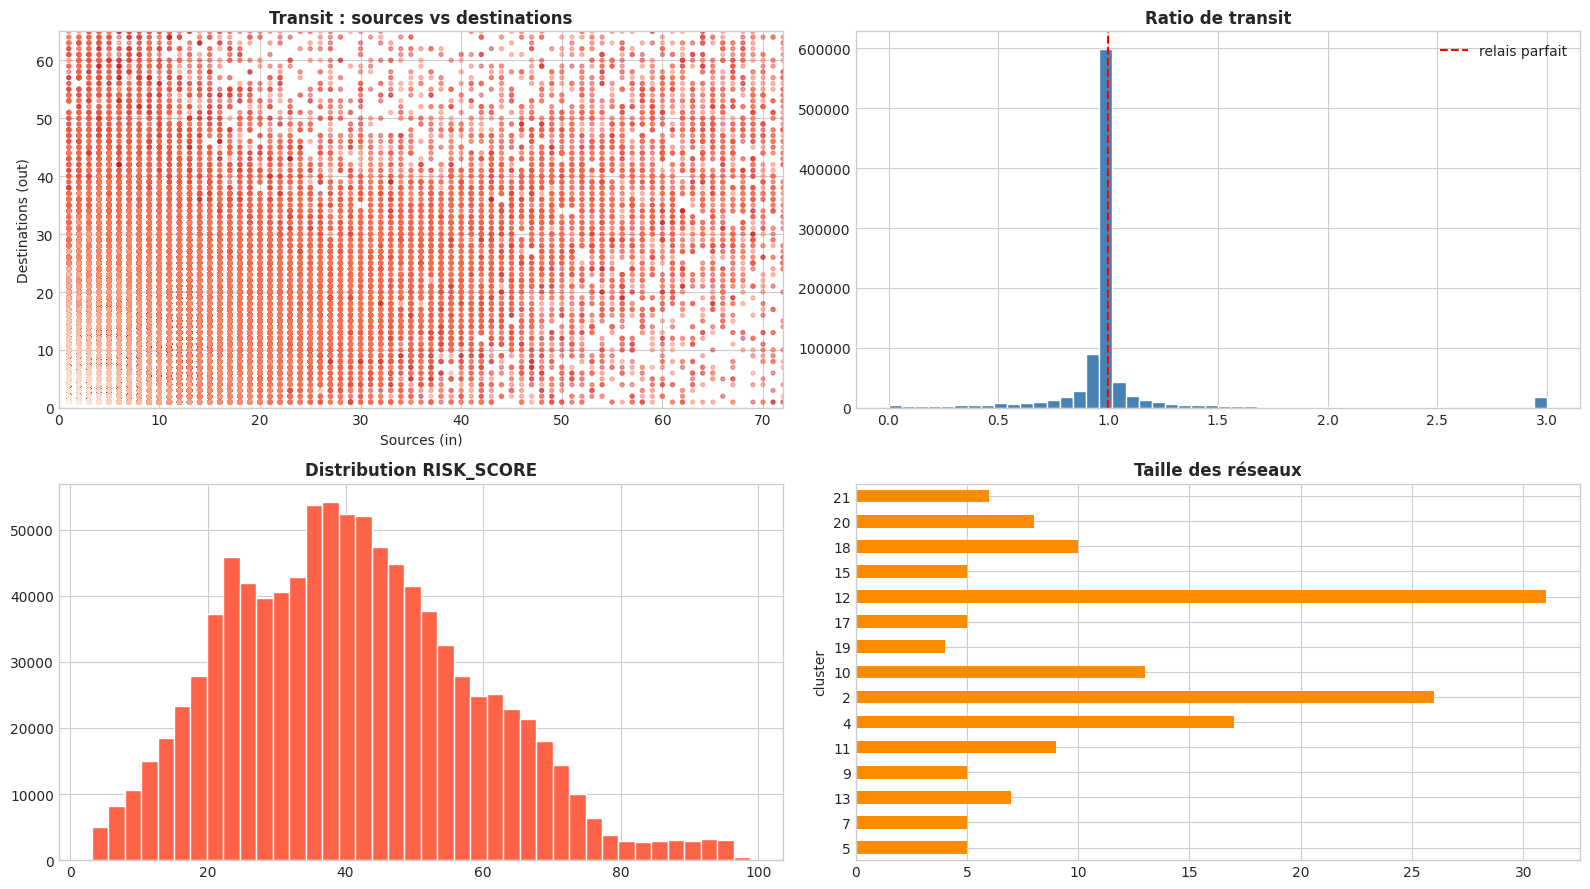

In [10]:
fig, axes = plt.subplots(2,2,figsize=(16,9))
axes[0,0].scatter(suspects['in_degree'], suspects['out_degree'],
    c=suspects['RISK_SCORE'], cmap='Reds', s=8, alpha=0.4)
axes[0,0].set_xlabel('Sources (in)'); axes[0,0].set_ylabel('Destinations (out)')
axes[0,0].set_title('Transit : sources vs destinations', fontweight='bold')
axes[0,0].set_xlim(0, suspects['in_degree'].quantile(0.99))
axes[0,0].set_ylim(0, suspects['out_degree'].quantile(0.99))
axes[0,1].hist(suspects['ratio_transit'].clip(0,3), bins=50, color='steelblue', edgecolor='white')
axes[0,1].axvline(1, color='red', ls='--', label='relais parfait')
axes[0,1].set_title('Ratio de transit', fontweight='bold'); axes[0,1].legend()
axes[1,0].hist(suspects['RISK_SCORE'], bins=40, color='tomato', edgecolor='white')
axes[1,0].set_title('Distribution RISK_SCORE', fontweight='bold')
if n_clusters>0:
    reseaux.head(15)['taille'].plot(kind='barh', ax=axes[1,1], color='darkorange')
    axes[1,1].set_title('Taille des réseaux', fontweight='bold')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'m2v2_analyse.png', dpi=150); plt.show()

## CELLULE 10 — Export (production)

In [11]:
joblib.dump(scaler, MODEL_DIR/'scaler.pkl')
joblib.dump(db, MODEL_DIR/'dbscan.pkl')
params = {
    'version':'v2 - production (transit+pagerank+dbscan)',
    'FEATURES':FEAT_M2, 'poids':{'transit':0.35,'diversite':0.25,'pagerank':0.20,'cluster':0.20},
    'dbscan_eps':1.5,'dbscan_min_samples':5,
    'budget_mules':BUDGET_MULES,
    'n_transit':int(len(suspects)),'n_clusters':int(n_clusters),
}
with open(MODEL_DIR/'params_v2.json','w') as f:
    json.dump(params, f, indent=2, default=str)

cols_exp=['node','in_degree','out_degree','in_montant','out_montant',
          'ratio_transit','transit_score','diversite','pagerank',
          'cluster','RISK_SCORE']
suspects[cols_exp].to_parquet(OUTPUT_DIR/'scored_v2.parquet', index=False)
alertes[cols_exp+['RAISON']].to_csv(OUTPUT_DIR/'alertes_v2.csv', index=False, encoding='utf-8-sig')
edges_t.to_parquet(OUTPUT_DIR/'edges_graph.parquet', index=False)  # pour viz dashboard

print('Exports créés dans outputs/M2_mules/')
print(f'\n=== RÉSUMÉ M2 v2 ===')
print(f'Comptes de transit : {len(suspects):,}')
print(f'Réseaux organisés  : {n_clusters}')
print(f'Alertes (budget)   : {len(alertes):,}')
print(f'Modèles sauvés     : scaler.pkl, dbscan.pkl, params_v2.json')

Exports créés dans outputs/M2_mules/

=== RÉSUMÉ M2 v2 ===
Comptes de transit : 968,026
Réseaux organisés  : 22
Alertes (budget)   : 500
Modèles sauvés     : scaler.pkl, dbscan.pkl, params_v2.json
